In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
np.random.seed(42)

In [7]:
n = 150
sales_df = pd.DataFrame({
    "Order_ID": range(1001, 1001+n),
    "Customer_ID": np.random.randint(1, 41, n),
    "Product": np.random.choice(["Laptop","Mobile","Tablet","Accessories"], n),
    "Region": np.random.choice(["North","South","East","West"], n),
    "Quantity": np.random.randint(1, 6, n),
    "Unit_Price": np.random.choice([8000,15000,25000,40000,60000], n),
    "Order_Date": pd.date_range("2024-01-01", periods=n)
})
sales_df


,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date
0,1001,27,Accessories,West,5,60000,2024-01-01
1,1002,17,Laptop,East,4,60000,2024-01-02
2,1003,9,Tablet,North,5,15000,2024-01-03
3,1004,33,Laptop,South,4,15000,2024-01-04
4,1005,20,Accessories,South,5,8000,2024-01-05
...,...,...,...,...,...,...,...
145,1146,30,Tablet,South,2,15000,2024-05-25
146,1147,17,Accessories,North,3,8000,2024-05-26
147,1148,26,Laptop,East,3,8000,2024-05-27
148,1149,36,Accessories,South,4,40000,2024-05-28


In [6]:
sales_df.shape


(150, 7)

In [8]:
sales_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order_ID     150 non-null    int64         
 1   Customer_ID  150 non-null    int32         
 2   Product      150 non-null    object        
 3   Region       150 non-null    object        
 4   Quantity     150 non-null    int32         
 5   Unit_Price   150 non-null    int64         
 6   Order_Date   150 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int32(2), int64(2), object(2)
memory usage: 7.2+ KB


In [9]:
sales_df.isnull().sum()


Order_ID       0
Customer_ID    0
Product        0
Region         0
Quantity       0
Unit_Price     0
Order_Date     0
dtype: int64

In [10]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["Unit_Price"]
sales_df.head()


,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date,Revenue
0,1001,27,Accessories,West,5,60000,2024-01-01,300000
1,1002,17,Laptop,East,4,60000,2024-01-02,240000
2,1003,9,Tablet,North,5,15000,2024-01-03,75000
3,1004,33,Laptop,South,4,15000,2024-01-04,60000
4,1005,20,Accessories,South,5,8000,2024-01-05,40000


In [11]:
import os
os.makedirs("outputs", exist_ok=True)
sales_df.to_csv("outputs/sales_data.csv", index=False)


In [12]:
sales_df["Revenue"].describe()


count       150.000000
mean      87346.666667
std       76414.797635
min        8000.000000
25%       30000.000000
50%       60000.000000
75%      120000.000000
max      300000.000000
Name: Revenue, dtype: float64

In [13]:
product_revenue = sales_df.groupby("Product")["Revenue"].sum()
product_revenue


Product
Accessories    2611000
Laptop         3356000
Mobile         3646000
Tablet         3489000
Name: Revenue, dtype: int64

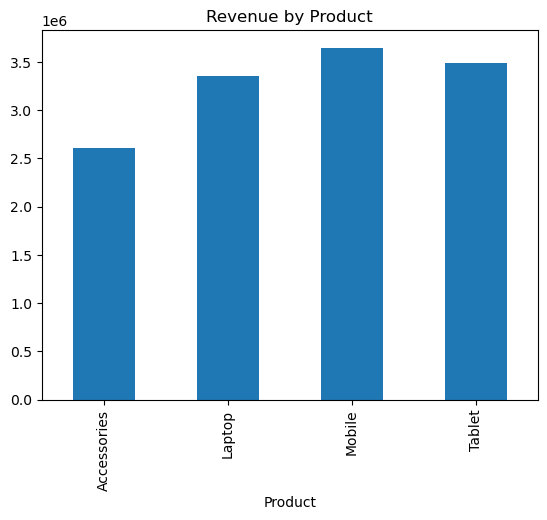

In [14]:
product_revenue.plot(kind="bar")
plt.title("Revenue by Product")
plt.show()


In [15]:
region_revenue = sales_df.groupby("Region")["Revenue"].sum()
region_revenue


Region
East     3405000
North    3214000
South    3535000
West     2948000
Name: Revenue, dtype: int64

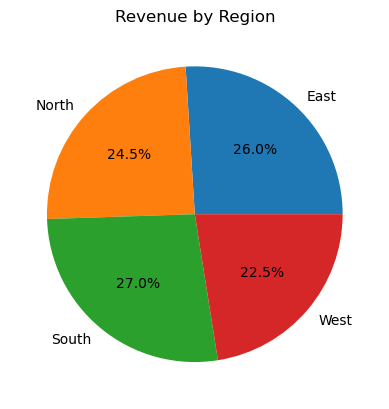

In [16]:
region_revenue.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue by Region")
plt.ylabel("")
plt.show()


In [20]:
daily_revenue = sales_df.groupby("Order_Date")["Revenue"].sum()
daily_revenue.head()


Order_Date
2024-01-01    300000
2024-01-02    240000
2024-01-03     75000
2024-01-04     60000
2024-01-05     40000
Name: Revenue, dtype: int64

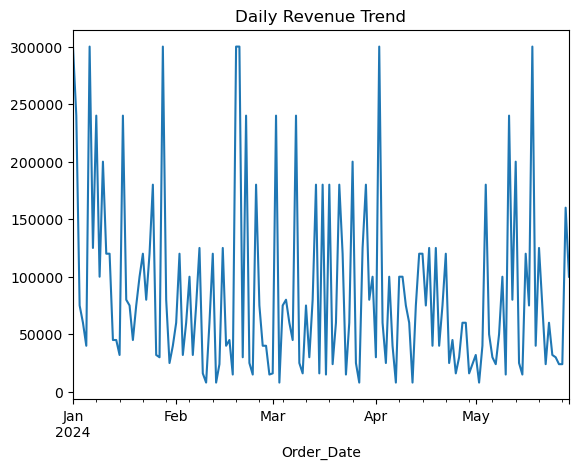

In [21]:
daily_revenue.plot()
plt.title("Daily Revenue Trend")
plt.show()


In [22]:
customer_summary = sales_df.groupby("Customer_ID").agg({
    "Revenue":"sum",
    "Order_ID":"count",
    "Quantity":"sum"
})
customer_summary.head()


,Revenue,Order_ID,Quantity
Customer_ID,,,
1,980000,7,24
2,337000,3,12
3,152000,4,9
4,113000,4,5
5,521000,9,24


In [24]:
customer_summary.to_csv("outputs/customer_summary.csv")


In [26]:
customer_summary.sort_values("Revenue", ascending=False).head(10)


,Revenue,Order_ID,Quantity
Customer_ID,,,
1,980000,7,24
34,940000,8,26
27,840000,5,23
21,736000,6,19
10,580000,5,19
13,545000,5,13
26,539000,6,20
17,526000,8,20
5,521000,9,24


In [27]:
product_summary = sales_df.groupby("Product").agg({
    "Revenue":"sum",
    "Quantity":"sum",
    "Order_ID":"count"
})
product_summary


,Revenue,Quantity,Order_ID
Product,,,
Accessories,2611000,92,34
Laptop,3356000,98,31
Mobile,3646000,124,43
Tablet,3489000,132,42


In [29]:
product_summary.to_csv("outputs/product_summary.csv")
